# 멀티모달 RAG Part 3: ColQwen 기반 시각적 검색

![colpali-architecture](https://cdn-uploads.huggingface.co/production/uploads/60f2e021adf471cbdf8bb660/La8vRJ_dtobqs6WQGKTzB.png)

- 이미지 출처: [HuggingFace Blog - ColPali](https://huggingface.co/blog/manu/colpali)

---

## 개요

**ColQwen**은 OCR 없이 문서 이미지를 직접 검색하는 **시각적 검색(Visual Retrieval)** 모델입니다.

기존 RAG 파이프라인:
```
PDF → OCR → 텍스트 추출 → 청킹 → 임베딩 → 벡터 DB → 검색
```

ColQwen 파이프라인:
```
PDF → 이미지 변환 → Vision Encoder → 멀티벡터 임베딩 → 검색
```

---

## 학습 목표

1. **Late Interaction (MaxSim)** 기반 멀티벡터 검색 원리 이해
2. **ColPali vs ColQwen** 아키텍처 차이점 파악
3. **byaldi/colpali-engine**을 활용한 문서 인덱싱 및 검색 구현
4. **End-to-End RAG 파이프라인** 구축 (검색 + VLM 답변 생성)

---

## 환경 설정

### Google Colab 실행 시

**T4 GPU (무료)** 환경에서 실행 가능합니다.

1. 런타임 > 런타임 유형 변경 > **GPU (T4)** 선택
2. 아래 셀 실행 시 자동으로 패키지 설치

### 로컬 환경 설정

```bash
# ColPali/ColQwen 엔진
uv add byaldi colpali-engine

# PDF 변환 도구
uv add pdf2image pillow

# Qwen2-VL 유틸리티
uv add qwen-vl-utils transformers accelerate

# GPU 최적화 (선택)
uv add bitsandbytes

# 시스템 요구사항 (poppler)
# macOS: brew install poppler
# Ubuntu: sudo apt-get install -y poppler-utils
```

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Google Colab 환경 감지됨")
    print("📦 의존성 해결 및 패키지 설치 중...")

    # [1] torch 3형제를 가장 먼저 고정한다.
    #     이유: 뒤에 설치되는 패키지들이 torch 를 의존성으로 끌고 오면서
    #     제각각 다른 버전으로 덮어쓰는 것을 막기 위함 (설치 순서 = 우선순위).
    #     ⚠️ --extra-index-url 은 '이 인덱스도 후보에 추가'라는 뜻일 뿐 강제가 아니다.
    #        Colab 기본 이미지가 이미 cu128 휠을 갖고 있으면 최종본은 2.8.0+cu128 이 된다.
    !pip install -q --upgrade torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --extra-index-url https://download.pytorch.org/whl/cu121

    # [2] 검색 스택: byaldi(고수준 API) + colpali-engine(저수준 API) + PDF→이미지 변환
    !pip install -q byaldi colpali-engine pdf2image pillow
    !pip install -q qwen-vl-utils transformers accelerate bitsandbytes

    # [3] LoRA 어댑터 로더(peft) 업그레이드
    #     ⚠️ 상한이 없어서 colpali-engine 0.3.15 가 요구하는 peft<0.19.0 을 넘어선다.
    #        실행에는 문제가 없었지만(아래 출력 참고), 재현성을 위해 실무에서는
    #        "peft>=0.18.0,<0.19.0" 처럼 상한을 명시하는 것을 권장한다.
    !pip install -q --upgrade "peft>=0.17.0" "torchao>=0.16.0"

    # [4] poppler: pdf2image 가 내부적으로 호출하는 PDF 렌더러 (없으면 인덱싱 단계에서 실패)
    !apt-get install -y poppler-utils > /dev/null 2>&1

    # [5] PDF 를 Google Drive 에서 읽는 경우에만 필요 (직접 업로드만 쓴다면 생략 가능)
    from google.colab import drive
    drive.mount('/content/drive')

    print("\n" + "="*40)
    print("✅ 모든 설정이 완료되었습니다!")
    # ⚠️ 재시작이 필수인 이유: Colab 은 이미 구버전 torch/numpy 를 import 해 둔 상태다.
    #    파일만 교체되고 메모리의 모듈은 그대로라 재시작 없이는 undefined symbol 에러가 난다.
    print("⚠️  반드시 [런타임] -> [런타임 다시 시작]을 실행해주세요!")
    print("="*40)
else:
    print("💻 로컬 환경에서 실행 중")

🌐 Google Colab 환경 감지됨
📦 의존성 해결 및 패키지 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 22.6 MB/s eta 0:00:00

### (1) 환경 변수 로드

> 이 노트북의 파이프라인(ColQwen2 / ColQwen2.5 / Qwen2-VL / Qwen3-VL)은 **전부 로컬에서 도는 오픈 웨이트 모델**이라
> **API 키가 전혀 필요 없습니다**. `.env` 가 필요한 경우는 다음뿐입니다.
>
> | 상황 | 필요한 값 |
> |---|---|
> | HuggingFace **게이트 모델** 다운로드 | `HF_TOKEN` |
> | 답변 생성을 GPT-4o/Claude 같은 API 모델로 교체 | 해당 provider 키 |
> | Langfuse 로 검색·생성 추적 | `LANGFUSE_*` |

In [1]:
from dotenv import load_dotenv
load_dotenv()

False

### (2) 기본 라이브러리

In [2]:
import os
import io
from pathlib import Path
from pprint import pprint

import warnings
warnings.filterwarnings('ignore')

import sys
IN_COLAB = 'google.colab' in sys.modules

---

## 1. 이론적 배경

### 1.1 기존 RAG의 한계

> 🔰 **쉽게**: 기존 RAG는 "PDF를 글자로 변환(OCR) → 검색" 방식인데, 이 첫 단계에서 대부분 망가집니다.

**전통적 파이프라인**
```
PDF ─▶ OCR ─▶ 텍스트 ─▶ 임베딩 ─▶ 벡터DB ─▶ 검색
        ↑ 여기서 모든 문제 시작
```

**3대 문제점**

| 문제 | 현실 예시 |
|---|---|
| 🐢 **속도 병목** | 500p PDF OCR에 수십 분 |
| 😵 **한국어 품질** | 다양한 폰트·HWP→PDF 변환 시 인코딩 오류 |
| 📊 **시각 정보 손실** | 표 병합 구조, 차트 축, 수식 위·아래첨자 |

**ColQwen의 해법**: OCR 단계 제거 → **페이지 이미지 자체**를 임베딩. 사람이 문서를 눈으로 훑듯이 검색.

### 1.2 Retrieval 패러다임 스펙트럼

> 🔰 **쉽게**: 문서 검색은 "빠르지만 대충" ↔ "정확하지만 느림" 스펙트럼 위에 있고, **Late Interaction**은 그 **중간 균형점**입니다.

**3가지 방식 비교**

| 방식 | 대표 모델 | 정확도 | 지연 | 저장 |
|---|---|---|---|---|
| **Bi-Encoder** (단일 벡터) | BGE, text-embedding-3 | 중 | ⚡ 매우 낮음 | 낮음 |
| **Late Interaction** (토큰별) | ColBERT, **ColPali/ColQwen** | 높음 | 낮음 | **높음** |
| **Cross-Encoder** (통째) | BERT reranker, Cohere-rerank | 매우 높음 | 🐌 매우 높음 | — |

<br>

> 💡 **비유**
> - **Bi-Encoder**: 책 한 줄 요약만 보고 고르기
> - **Late Interaction**: 목차+소제목까지 보고 고르기
> - **Cross-Encoder**: 책 전체를 읽고 판단

**Late Interaction의 핵심 아이디어**
- 문서는 미리 **토큰별 벡터 행렬**로 인덱싱 (오프라인)
- 쿼리 시점엔 **MaxSim**(빠른 행렬곱)만 계산 → 토큰 정밀도 + 대규모 검색 양립

**계보**
```
ColBERT (SIGIR 2020)
  └─ ColBERTv2 (2022) — PLAID 압축
      └─ ColPali (arXiv:2407.01449, 2024) — OCR-free 문서검색
          └─ ColQwen (Qwen2-VL 기반)
              └─ ColQwen-Omni (2026) — 이미지+오디오+비디오
```

### 1.3 Late Interaction (MaxSim)

> 🔰 **쉽게**: 쿼리 토큰 하나하나가 문서에서 **각자 자기와 가장 비슷한 토큰**을 찾아 점수 매기고 합산합니다.

**수식**
$$\text{Score}(q, d) = \sum_{i \in q} \max_{j \in d} \text{sim}(q_i, d_j)$$

**그림으로 보면**
```
쿼리:  [어떤] [attention] [메커니즘]
          ↓       ↓            ↓    ← 각자 최고 점수 토큰 찾기
문서:  [이것은] [attention is] [어텐션은]
       0.3     0.9            0.7      → 합계: 1.9
```

---

#### "Late"(늦은) Interaction 이름 설명

이름의 핵심은 **"쿼리와 문서가 언제 처음 만나는가"** 입니다. 세 방식은 만나는 시점이 다릅니다.

```
① No Interaction (Bi-Encoder)          ② Late Interaction (ColBERT/ColPali)      ③ Early Interaction (Cross-Encoder)

  쿼리 ─▶[인코더]─▶ ● (벡터 1개)          쿼리 ─▶[인코더]─▶ ●●●● (토큰별)                     쿼리 ┐
                     │                                        │                          ├─▶[인코더]─▶ 점수
  문서 ─▶[인코더]─▶ ● (벡터 1개)          문서 ─▶[인코더]─▶ ●●●●●●●● (토큰별)                 문서 ┘
                     │                                        │                     (둘을 붙여서 함께 인코딩)
                     ▼                                        ▼
                  코사인 1회                         MaxSim (토큰 × 토큰)
```

| 관점 | ① Bi-Encoder | ② **Late Interaction** | ③ Cross-Encoder |
|---|---|---|---|
| 만나는 시점 | 인코딩 **후**, 벡터 1쌍 | 인코딩 **후**, 토큰 전체 | 인코딩 **중** (모든 레이어에서 섞임) |
| 문서 사전 계산 | ✅ 가능 | ✅ **가능** ← 결정적 | ❌ 불가능 (쿼리마다 재계산) |
| 표현력 | 낮음 (정보 압축 심함) | **중~높음** | 최고 |
| 10,000 페이지 검색 비용 | 행렬곱 1회 | 행렬곱 1회(큰 텐서) | **모델 forward 10,000회** ← 실용 불가 |

<br>

> 🎯 **한 문장**: Late Interaction은 **"문서를 미리 인코딩해 둘 수 있는 마지막 지점"** 까지 상호작용을 미룬 설계입니다.
> 한 단계만 더 미루면(=Cross-Encoder) 사전 계산이 불가능해지고, 한 단계 앞당기면(=Bi-Encoder) 토큰 정보가 사라집니다.

인덱싱(4절, 15페이지 한 번)과 검색(쿼리마다)이 **분리**되는 이유입니다.

---

#### 🔬 실제 구현은 한 줄이다

`colpali-engine` 의 참조 구현(`colpali_engine/utils/maxsim.py`)은 정확히 이렇습니다.

```python
def _torch_maxsim(query, doc):
    # query: (B_q, L_q, 128)   doc: (B_d, L_d, 128)
    return torch.einsum("bnd,csd->bcns", query, doc).amax(dim=3).sum(dim=2)
    #                    └───── ①  ─────┘  └── ② ──┘  └── ③ ──┘
```

| 단계 | 연산 | 결과 shape | 의미 |
|---|---|---|---|
| ① `einsum` | 모든 (쿼리토큰 × 문서토큰) 내적 | `(B_q, B_d, L_q, L_d)` | 유사도 행렬 — 셀 아래 히트맵의 대형 버전 |
| ② `.amax(dim=3)` | 문서 토큰 축에서 **최댓값** | `(B_q, B_d, L_q)` | 쿼리 토큰마다 "가장 잘 맞는 문서 조각" 하나 선택 |
| ③ `.sum(dim=2)` | 쿼리 토큰 축 **합** | `(B_q, B_d)` | 최종 점수 행렬 |

**이 노트북의 실제 숫자를 넣어보면**

```
쿼리 "attention mechanism" → 약 25 토큰 (증강 토큰 포함, §1.5)
문서 페이지 1장            → 약 780 토큰
차원                       → 128

유사도 행렬:  (25, 780)  = 19,500개 내적
연산량:       25 × 780 × 128 ≈ 250만 곱셈-덧셈 ≈ 5 MFLOP / 페이지
15페이지:     약 75 MFLOP  → GPU에서 ms 단위
10,000페이지: 약 50 GFLOP  → T4에서도 수십~수백 ms
```

> 💡 **저비용**: 문서 쪽 벡터는 **이미 만들어져 있고**, 검색 시점에 도는 것은 **행렬곱 하나**뿐입니다.
> Cross-Encoder라면 여기서 20억 파라미터 모델을 10,000번 돌려야 합니다.

---

#### 대용량 문서로 확장하려면

| 전략 | 방법 | 효과 |
|---|---|---|
| **2단계 검색** | 토큰 벡터로 ANN(HNSW/IVF) → 후보 1,000장만 MaxSim 재랭크 | O(N) → O(log N + 1000) |
| **PLAID / FastPlaid** | 잔차 압축 + centroid pruning (`score_multi_vector` 옆에 `get_topk_plaid` 로 제공) | 저장 1/16~1/32, 지연 ↓ |
| **풀링(pooling)** | 유사한 패치 토큰을 클러스터링해 768 → 128개로 축소 | 저장 6배 절감, 성능 손실 소폭 |
| **전용 엔진** | Vespa / Qdrant의 multi-vector 인덱스 | 운영 도구 일체 제공 |

**장점 (한 줄 요약)**
- 토큰 단위 정밀 매칭 → 긴 문서·세부 구문 검색 강함
- 미분 가능·행렬곱 기반 → GPU에서 빠름
- **문서 임베딩 사전 계산 가능** → 검색 시점 비용이 Cross-Encoder의 수천분의 1

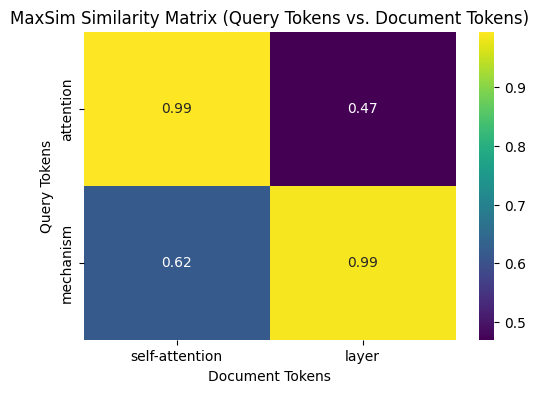


MaxSim 점수: 1.9835


In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

def maxsim_score(query_vecs, doc_vecs):
    """
    ColBERT-style MaxSim 연산

    Args:
        query_vecs: (n_query_tokens, dim) 쿼리 벡터
        doc_vecs: (n_doc_tokens, dim) 문서 벡터

    Returns:
        float: MaxSim 점수
    """
    similarity_matrix = cosine_similarity(query_vecs, doc_vecs)
    max_sims = similarity_matrix.max(axis=1)
    return max_sims.sum(), similarity_matrix


# 예제: "attention mechanism" 쿼리
query_vecs = np.array([
    [0.8, 0.2, 0.1],  # "attention"
    [0.3, 0.9, 0.2],  # "mechanism"
])

# 문서: "self-attention layer"
doc_vecs = np.array([
    [0.75, 0.25, 0.15],  # "self-attention"
    [0.2, 0.85, 0.3],    # "layer"
])

score, sim_matrix = maxsim_score(query_vecs, doc_vecs)

plt.figure(figsize=(6, 4))
sns.heatmap(sim_matrix, annot=True, cmap='viridis', fmt=".2f",
            xticklabels=['self-attention', 'layer'],
            yticklabels=['attention', 'mechanism'])
plt.title('MaxSim Similarity Matrix (Query Tokens vs. Document Tokens)')
plt.xlabel('Document Tokens')
plt.ylabel('Query Tokens')
plt.show()

print(f"\nMaxSim 점수: {score:.4f}")


#### 출력 결과: MaxSim 연산 과정 해석

**출력값**: `MaxSim 점수: 1.9835` + 2×2 히트맵

**유사도 행렬 (쿼리 2토큰 × 문서 2토큰)**

|  | `self-attention` | `layer` | **행 최댓값** |
|---|---|---|---|
| **`attention`** | **0.9934** | 0.3841 | 0.9934 |
| **`mechanism`** | 0.4842 | **0.9901** | 0.9901 |

<br>

- **MaxSim 계산**: $0.9934 + 0.9901 = \mathbf{1.9835}$ — 즉 **행별 최댓값의 합**
- 대각선이 밝게(0.99) 나오는 것은 두 쿼리 토큰이 서로 **다른** 문서 토큰을 골랐다는 뜻입니다.
  MaxSim은 매칭을 1:1로 강제하지 않으므로, 두 쿼리 토큰이 **같은** 문서 토큰을 고를 수도 있습니다(그리디, 비배타적).

**핵심 시사점**

- Dense Single-Vector는 문장 전체를 하나로 평균하므로 세부 단어 의미가 희석됩니다.
- Late Interaction은 각 쿼리 토큰이 **독립적으로** 최적 상대를 찾아 합산 → 긴 문서 안의 기술 용어·도표 캡션 매칭에 강합니다.
- **비대칭 연산**: $\text{Score}(q,d) \ne \text{Score}(d,q)$. 쿼리 쪽에서만 max를 취하므로
  "문서에는 있는데 쿼리에 없는 내용"은 감점되지 않습니다 → 긴 문서가 구조적으로 유리(길이 편향).

> 🧪 **직접 확인해 보세요**: `max_sims.sum()` 을 `max_sims.mean()` 으로 바꾸면 점수가 길이에 무관해집니다.
> 실제 ColBERT/ColPali가 **sum** 을 쓰는 이유는, 쿼리 길이가 고정된 상황에서 sum이 학습 신호를 더 크게 주기 때문입니다.

**데모 예제 ↔ 실제 ColQwen 대응표**

| | 위 데모 | 실제 ColQwen2.5 |
|---|---|---|
| 쿼리 벡터 | `(2, 3)` | `(≈25, 128)` (증강 토큰 포함) |
| 문서 벡터 | `(2, 3)` | `(≈783, 128)` (시각 768 + 프롬프트 토큰) |
| 유사도 행렬 | `(2, 2)` | `(25, 783)` = 19,575개 내적 |
| 구현 | `cosine_similarity` + `.max(axis=1).sum()` | `torch.einsum("bnd,csd->bcns").amax(3).sum(2)` |
| 정규화 | `cosine_similarity` 가 내부에서 처리 | 모델이 **미리** L2 정규화해 저장 → 내적 = 코사인 |

### 1.4 Single vs Multi-Vector: 복잡도 트레이드오프

> 🔰 **쉽게**: 정밀도를 얻으면 저장소가 1000배 커집니다. 실무에선 압축 기법으로 완화해요.

**점수 공식 한 줄 비교**

| 방식 | 공식 | 의미 |
|---|---|---|
| Single-Vector | `sim(E(q), E(d))` | 문서 전체를 벡터 1개로 압축 |
| **Multi-Vector** | `Σᵢ maxⱼ sim(qᵢ, dⱼ)` | 토큰별 그리디 정렬 |

**복잡도 차이**

| 항목 | Single | Multi |
|---|---|---|
| 저장 | `O(N·d)` | `O(N·T·d)` (T배 ↑) |
| 검색 | `O(\|q\|·N·d)` | `O(\|q\|·N·T·d)` |

**실제 숫자 감 잡기**
- 문서 1,000개 × 평균 1,024 토큰 × 128-dim
- Single: **500KB** / Multi: **500MB** ← 1,000배 차이!

**실무에서 사용 가능한 이유**
1. **PLAID 압축** (ColBERTv2): 1/16까지 축소
2. **Centroid Pruning**: 대표 토큰만 비교
3. **GPU 행렬곱**: MaxSim은 실제로 매우 빠름
4. **품질 게인**: BEIR/DocVQA에서 +10~20점

> 📝 **저장 dtype 확인법**: byaldi 는 기본적으로 **bfloat16** 경로를 타고, 이 노트북의 colpali-engine 코드는
> `torch_dtype=torch.float16` 을 명시했습니다. 두 경로의 점수 소수점 자리를 비교하면 이 차이가 그대로 드러납니다
> (섹션 4의 분석 셀 참고). 프로덕션에서는 PLAID·이진 양자화로 한 단계 더 줄입니다.

### 1.5 이미지가 멀티벡터가 되기까지: 임베딩 생성 원리

> 🔰 **쉽게**: 페이지 이미지를 **작은 타일**로 쪼개고, 그 타일들을 **언어모델에 통째로 읽힌 다음**,
> 각 타일이 남긴 표현을 128차원으로 눌러 담습니다. 그래서 텍스트 쿼리와 같은 공간에서 만날 수 있습니다.

---

#### 1️⃣ 왜 이미지를 "토큰"으로 바꾸는가

**ViT의 이미지 → 토큰 변환**
```
입력 이미지
      │
      ▼ 14×14 픽셀 패치로 분할
      ┌─┬─┬─┬─┬─┐
      │ │ │ │ │ │  ← 각 칸이 1개 패치
      ├─┼─┼─┼─┼─┤
      │ │ │ │ │ │
      └─┴─┴─┴─┴─┘
      │
      ▼ 각 패치를 d차원 벡터로 투영 + 위치 정보 부여
      (n_patches, d) 행렬  =  "단어 토큰 시퀀스"와 같은 형태
```

결과: 이미지가 **문장처럼** 취급되어 Self-Attention을 그대로 적용할 수 있습니다.

**OCR이 불필요한 이유**
- 각 패치 토큰은 그 영역의 **글자 모양·그림·선·여백**을 모두 담은 벡터입니다.
- 학습 과정(§1.3)에서 "attention diagram" 이라는 **쿼리 텍스트**와 **그림이 그려진 패치**가
  높은 유사도를 갖도록 정렬되었습니다.

> 💡 **비유**: 문서를 모자이크 타일로 쪼개면, 각 타일이
> "여기엔 'attention' 이라는 글자가 있다"·"여기엔 화살표가 있다"를 아는 벡터로 바뀝니다.

---

#### 2️⃣ 전체 파이프라인

`ColQwen2_5_Processor` + `ColQwen2_5` 가 페이지 1장에 대해 하는 일을 순서대로 따라갑니다.
100 DPI로 렌더한 Letter 페이지(**850 × 1100 px**)를 예로 듭니다.

```
[① smart_resize]  850×1100 px  ──▶  672×896 px      (28의 배수 + max_pixels 상한)
       │
[② 패치 분할]     14×14 px 패치  ──▶  48 × 64 = 3,072 패치
       │
[③ 2×2 병합]      spatial_merge  ──▶  24 × 32 = 768 시각 토큰   (각 토큰 = 원본 28×28 px)
       │
[④ 프롬프트 결합] "<|vision_start|> ⟨768개⟩ <|vision_end|>Describe the image." + 텍스트 토큰 ≈ 15개
       │                                                              → 시퀀스 길이 ≈ 783
[⑤ LLM forward]   Qwen2.5-VL 36개 레이어 통과 ──▶ last_hidden_state (783, 2048)
       │
[⑥ 투영 + 정규화] Linear(2048 → 128) → L2 normalize → × attention_mask
       │
       ▼
   페이지 임베딩  (783, 128)   ← 이것이 doc_embeddings 에 저장되는 실물
```

**단계별 상세**

| 단계 | 무엇을 하나 | 근거 (실제 설정/코드) |
|---|---|---|
| ① `smart_resize` | 가로·세로를 **28의 배수**로 맞추고, 총 픽셀이 `max_pixels` 를 넘으면 비율 유지 축소 | `patch_size=14`, `merge_size=2` → factor 28 / `max_pixels=602112` |
| ② 패치 분할 | 14×14 px 단위로 자름 | `672/14 × 896/14 = 48 × 64` |
| ③ 2×2 병합 | 인접 4개 패치를 1개 시각 토큰으로 합침 (토큰 수 1/4) | `spatial_merge_size=2` → `24 × 32 = 768` = `602112 / 784` |
| ④ 프롬프트 결합 | 이미지 토큰 앞뒤에 **고정 지시문**을 붙임 | `visual_prompt_prefix = "…<\|vision_start\|><\|image_pad\|><\|vision_end\|>Describe the image.<\|im_end\|><\|endoftext\|>"` |
| ⑤ LLM forward | **생성(LM head)이 아니라 `last_hidden_state` 를 꺼냄** | `output_hidden_states=True, use_cache=False` |
| ⑥ 투영·정규화 | 2048 → 128 선형 투영 후 L2 정규화, 패딩은 0으로 | `self.dim = 128`, `custom_text_proj = nn.Linear(hidden_size, 128)` |

---

#### 3️⃣ 여기서 반드시 짚어야 할 4가지

**① 🔑 LM head를 버리고 `last_hidden_state` 를 쓴다 — 이것이 ColPali의 핵심 아이디어**

```python
class ColQwen2_5(Qwen2_5_VLModel):        # ← "ForConditionalGeneration" 이 아니다
    self.dim = 128
    self.custom_text_proj = nn.Linear(hidden_size, self.dim)

    def forward(...):
        last_hidden_states = super().forward(..., output_hidden_states=True).last_hidden_state
        proj = self.custom_text_proj(last_hidden_states)     # (B, L, 128)
        proj = proj / proj.norm(dim=-1, keepdim=True)        # L2 정규화
        proj = proj * kwargs["attention_mask"].unsqueeze(-1) # 패딩 → 정확히 영벡터
        return proj
```

- 답변을 **생성하지 않습니다.** VLM을 **문맥 인코더**로만 씁니다.
- 그 결과 각 시각 토큰의 벡터는 ViT 원본 출력이 아니라, **언어모델 36개 레이어를 거쳐
  페이지 전체 문맥과 "Describe the image." 지시문까지 반영된 표현**입니다.
- 이것이 CLIP과의 결정적 차이입니다.

| | CLIP | **ColQwen** |
|---|---|---|
| 출력 | 이미지 1개당 **벡터 1개** | 이미지 1개당 **수백 개 벡터** |
| 인코더 | 이미지·텍스트 **별도 타워** | **하나의 VLM** 이 둘 다 처리 |
| 시각 표현 | ViT `[CLS]` 요약 | **LLM 문맥화된** 토큰별 표현 |
| 강한 작업 | 사진 ↔ 캡션 | **문서 페이지 ↔ 질문** (글자·표·레이아웃) |

**② 📌 문서 임베딩에는 "Describe the image." 프롬프트 토큰도 함께 들어간다**

`mask_non_image_embeddings` 기본값이 `False` 라, 반환되는 임베딩에는
시각 토큰 768개 **+ 프롬프트 텍스트 토큰 약 15개**가 모두 포함됩니다(총 ≈ 783).

- 4절에서 계산한 "페이지당 ≈196 KB"는 시각 토큰만 센 값이라 **실제로는 조금 더 큽니다**.
- 순수 이미지 토큰만 원하면 `ColQwen2_5.from_pretrained(..., mask_non_image_embeddings=True)` 를 씁니다.

**③ 🔤 쿼리 쪽은 이미지 없이 같은 모델을 통과한다**

```python
# colpali_engine/utils/processing_utils.py
suffix = self.query_augmentation_token * 10     # "<|endoftext|>" × 10
texts  = [self.query_prefix + text + suffix for text in texts]
```

- 쿼리 `"attention mechanism"` 은 실제로 **`"attention mechanism" + <|endoftext|>×10`** 이 되어 인코딩됩니다.
- **왜 빈 토큰 10개를 붙이나(query augmentation)**: 이 자리들이 "아직 말하지 않은 질문의 여백" 역할을 하며,
  문서 쪽에서 관련 있는 부분을 **추가로 끌어올 여지**를 만듭니다(ColBERT의 마스크 증강과 같은 아이디어).
- 부작용: 무관한 페이지도 이 토큰들이 어딘가와는 매칭되므로 **점수 하한이 0이 아닙니다.**
  이 노트북에서 최하위 페이지도 5~7점이 나오는 이유입니다.
- 쿼리 임베딩은 **길이가 짧아**(≈25 토큰) 검색 시점 비용이 무시할 만합니다.

**④ ⚖️ 문서와 쿼리가 같은 공간에 있는 이유**

둘 다 **같은 백본 + 같은 `custom_text_proj` 레이어**를 통과합니다.
Bi-Encoder처럼 타워가 두 개가 아니라 **하나의 모델**이 양쪽을 처리하므로,
학습(§1.3)에서 맞춰진 정렬이 그대로 유지됩니다.

---

#### 4️⃣ 학습 요약과 "OCR이 못 살리는 정보"

| 항목 | 내용 |
|---|---|
| 데이터 | 127,460개 (쿼리, 페이지 이미지) 쌍 — 학술 63% / 합성 웹 PDF 37% |
| Loss | in-batch InfoNCE (MaxSim 점수 행렬의 대각선이 정답, `temperature=0.02`) |
| Backbone | PaliGemma-3B (ColPali) / Qwen2-VL-2B · Qwen2.5-VL-3B (ColQwen) |
| 학습되는 부분 | **LoRA 어댑터(r=32) + 128차원 투영 레이어** — 백본 대부분은 동결 |
| 버려지는 부분 | **LM head (생성 헤드)** |

**OCR이 못 살리는 정보, ColPali/ColQwen은 보존**
- 📊 표의 병합 셀·경계선
- 📈 차트의 축 레이블과 데이터의 공간 관계
- 📐 수식의 위·아래첨자, 분수의 위아래 구조
- 🖼 그림 안에 그려진 레이블 (2.5절에서 `positional encoding` 이 **Figure 1 페이지**를 찾아낸 이유)
- 🇰🇷 한국어·HWP 변환 PDF에서 흔한 인코딩 깨짐

> 🧪 **직접 확인해 보기**: 4절에서 임베딩을 만든 뒤
> `processor_colqwen25.process_images([pdf_images[0]])["input_ids"].shape` 로 실제 시퀀스 길이를,
> `doc_embeddings[0].shape` 로 최종 임베딩 shape을 찍어 보세요.
> 위 6단계 표의 숫자(≈783 × 128)와 맞아떨어지는지 눈으로 확인하는 것이 가장 확실한 학습입니다.

### 1.6 ColPali vs ColQwen 한눈에

> 🔰 **쉽게**: 둘 다 ColVision 계열이지만, **한국어·고해상도 문서**라면 ColQwen이 확실히 유리합니다.

| 항목 | ColPali | **ColQwen** |
|---|---|---|
| Vision Encoder | SigLIP (고정 224×224) | **Qwen-Vision (동적 해상도)** |
| Language Model | Gemma-2B (영어 중심) | **Qwen2-VL-2B / Qwen2.5-VL-3B (다국어)** |
| 한국어 지원 | 제한적 | **우수** |
| 고해상도 처리 | 다운샘플링 필요 | **네이티브 지원** |
| Position Encoding | 1D RoPE | **M-ROPE (3D)** |

→ 상세 이유는 **1.7 절**에서 계속.

### 1.7 Qwen-Vision이 문서를 더 잘 보는 비결: 동적 해상도 + M-ROPE

ColQwen이 한국어 문서에서 특히 강한 이유는 **Qwen-Vision 인코더**가 문서 이미지를 다루는 방식 자체가 다르기 때문입니다. 

---

#### 🔍 ① 동적 해상도 — "원본 그대로 보기"

**기존 ViT의 문제: 사진을 무조건 썸네일로 만든다**

기존 Vision Transformer(ViT)는 입력을 반드시 **224×224 같은 고정 크기**로 맞춰야 합니다. 1920×1080 고해상도 문서 이미지가 들어와도 강제로 축소(다운샘플링)하죠.

> 💡 **비유**: A4 계약서를 명함 크기로 줄여 놓고 "글자 읽어봐"라고 하는 격입니다. 큰 제목은 보여도 본문은 뭉개집니다.

**Qwen-Vision의 해결책: NaViT 방식**

Qwen-Vision은 **원본 해상도를 그대로 받고**, 이미지 크기에 비례해 패치(토큰) 수를 가변적으로 만듭니다.

**토큰 수 계산식** (Qwen2-VL / Qwen2.5-VL 공통)

```
patch_size = 14        # ViT 패치 한 변 (px)
merge_size = 2         # 인접 2×2 패치를 1개 시각 토큰으로 병합
→ 시각 토큰 1개 = 원본 28×28 px 영역

시각 토큰 수 ≈ (W / 28) × (H / 28)
```

| 원본 이미지 | 기존 ViT (224² 고정) | Qwen-Vision (동적) |
|---|---|---|
| 1280×720 | 224×224로 축소 → **196 토큰** | (1280/28)×(720/28) ≈ **1,152 토큰** |
| 640×480 | 224×224로 축소 → **196 토큰** | (640/28)×(480/28) ≈ **391 토큰** |
| A4 100 DPI (850×1100) | 224×224로 축소 → **196 토큰** | 상한 규칙 적용 → **768 토큰** |

**상한·하한은 프로세서 설정으로 강제됩니다.** `vidore/colqwen2.5-v0.2` 의 `preprocessor_config.json` 실제 값:

```json
{"patch_size": 14, "merge_size": 2, "min_pixels": 3136, "max_pixels": 602112}
```

- `max_pixels = 602112 = 768 × 28 × 28` → **페이지당 최대 768 시각 토큰**
- `min_pixels = 3136 = 4 × 28 × 28` → 최소 4 토큰
- 즉 100 DPI로 렌더한 A4(약 935,000 px)는 내부에서 자동 축소되어 **768 토큰**에 맞춰집니다.
- `ColQwen2_5_Processor.from_pretrained(..., max_num_visual_tokens=1024)` 로 상한을 직접 올릴 수 있고,
  올리면 작은 글씨 인식이 좋아지는 대신 **저장 용량과 검색 시간이 비례해 늘어납니다**.

> 📊 **결과**: 큰 이미지는 더 많은 토큰으로 세밀하게, 작은 이미지는 적은 토큰으로 효율적으로 처리합니다. 표의 작은 숫자, 차트 범례 같은 **세부 정보가 보존**됩니다.

---

#### 🧭 ② M-ROPE — "이건 어디 위치?"를 알려주는 좌표

Transformer는 원래 "순서"만 알지 "2D 공간 위치"는 모릅니다. 그래서 위치 정보를 인코딩으로 주입해야 하는데, **ColPali는 1D**(선 위 순서)만, **ColQwen은 3D**(시간·세로·가로)를 씁니다.

> 💡 **비유**
> - **ColPali (1D)**: "이 단어는 전체에서 53번째야" 정도만 앎
> - **ColQwen (3D M-ROPE)**: "이 단어는 **페이지 상단**의 **왼쪽 열**에 있는 세 번째 줄이야" 까지 앎

| 축 | 의미 | 문서에서 왜 중요? |
|---|---|---|
| Temporal (시간) | 영상 프레임 순서 | 📄 문서(정지 이미지)에서는 모든 패치가 같은 값 → 사실상 비활성 |
| **Height (세로)** | 위↔아래 위치 | 📌 헤더·본문·푸터 구분 |
| **Width (가로)** | 왼쪽↔오른쪽 위치 | 📌 2단 레이아웃, 표의 열 구분 |

문서 이미지에서는 Height·Width 두 축만 쓰이는데, 이것만으로도 "**페이지 상단의 제목**", "**왼쪽 열의 표**", "**하단 각주**" 같은 레이아웃 구조를 모델이 인식할 수 있습니다.

---

#### 🇰🇷 ③ 한국어가 특히 잘 되는 이유

두 모델의 **LLM 기반(backbone)** 이 다르다는 점이 결정적입니다.

| 항목 | ColPali | ColQwen |
|---|---|---|
| 기반 LLM | Gemma-2B (**영어 중심**) | Qwen2/2.5-VL (**29개 언어, 한국어 포함**) |
| 한국어 토크나이저 | "안녕하세요" → `[안, 녕, 하, 세, 요]` 처럼 단편화 | `[안녕, 하세요]` 처럼 의미 단위로 분할 |
| 사전학습 데이터 | 주로 영문 문서 | 중·영·한 다국어 문서 대량 포함 |

<br>

**실전 의미**: 한국어 쿼리("삼성전자 3분기 영업이익")와 문서 이미지 속 한국어 텍스트가 **같은 임베딩 공간에 잘 정렬**되므로, 한국 금융·법률·공공문서 검색에서 ColPali보다 확연히 높은 정확도를 보입니다.

> ⚠️ **단, 검증 없는 일반화 금지**: ViDoRe V3의 한국어 서브셋 같은 공개 벤치마크는 있지만
> **여러분의 문서**(스캔 품질·폰트·양식)에서의 우열은 다를 수 있습니다.
> 자체 골든셋 30~50쌍이라도 만들어 Recall@5 를 재보는 것이 유일하게 신뢰할 만한 근거입니다.

---

#### 🎯 한 줄 요약

> **Qwen-Vision = 문서를 원본 그대로 보며(동적 해상도), 2D 좌표를 이해하고(M-ROPE), 한국어를 네이티브로 다루는 인코더**

이 세 가지가 합쳐져서 ColQwen이 한국어 문서 검색의 강력한 선택지가 됩니다.

### 1.8 2026년 ColVision 모델 지형

> 🔰 **쉽게**: 2024년 ColPali 이후 모델이 쏟아졌어요. 목적에 맞는 걸 고르세요.

**주요 공식 모델 (`vidore/*`)**

| 모델 | 백본 | 백본 크기 | 언어 | 특징 |
|---|---|---|---|---|
| `colpali-v1.3-merged` | PaliGemma2 | 3B | 영어 | 영문 최고 성능 |
| `colqwen2-v1.0` | **Qwen2-VL-2B-Instruct** | 2B | **한국어 우수** | 29+ 언어, 최대 768 패치 |
| `colqwen2.5-v0.2` | **Qwen2.5-VL-3B-Instruct** | **3B** | **한국어 우수** | 동적 해상도, 최신 |
| `colSmol-256M/500M` | SmolVLM | ≤500M | 영어 | CPU·엣지용 |

<br>

**🔑 체크포인트는 "모델"이 아니라 "LoRA 어댑터"**

`vidore/colqwen2-v1.0` 저장소에서 실제로 받는 파일은 `adapter_model.safetensors` **74 MB** 하나뿐입니다
(ColQwen2.5는 240 MB). 나머지 수 GB의 백본은 HuggingFace 가 **자동으로 별도 다운로드**합니다.

| 항목 | ColQwen2-v1.0 | ColQwen2.5-v0.2 |
|---|---|---|
| 어댑터 크기 | 74 MB | 240 MB |
| LoRA 설정 | `r=32, alpha=32` | `r=32, alpha=32` |
| 학습 데이터 | 127,460 query-page 쌍 (학술 63% + 합성 웹 PDF 37%) | 동일 |
| 임베딩 차원 | **128** | **128** |
| 라이선스 | 어댑터 MIT / 백본 Apache-2.0 | 동일 |

<br>

> 💡 왜 LoRA인가: 백본의 생성(LM) head 는 버리고 **인코더만** 쓰면서, 마지막에 128차원 투영 레이어를 붙입니다.
> 전체 파인튜닝 대비 학습 비용이 극적으로 낮고, 백본 하나로 여러 어댑터를 갈아 끼울 수 있습니다.

**실험적 (colpali-engine ≥0.3.15)**
- **ColQwen3 / BiQwen3**: Qwen3-VL 기반 — modeling 코드는 있으나 **`vidore` 공식 체크포인트는 아직 미공개**
  (커뮤니티 모델 예: `TomoroAI/tomoro-colqwen3-embed-4b`, 임베딩 차원 320, `AutoModel + trust_remote_code=True` 로 로드)
- **ColQwen-Omni**: 이미지+오디오+비디오 통합 검색

**벤치마크: ViDoRe V3 (2026)**

| 항목 | 내용 |
|---|---|
| 제작 | ILLUIN Technology + NVIDIA |
| 규모 | **10개 데이터셋 / 26,000+ 페이지 / 3,099 쿼리 / 6개 언어** (8개 공개 + 2개 비공개) |
| 특징 | 합성이 아닌 **사람이 만들고 검증한** 관련도·바운딩박스·정답 (약 12,000 시간 어노테이션) |
| 논문 | [arXiv:2601.08620](https://arxiv.org/abs/2601.08620) · [HF 블로그](https://huggingface.co/blog/QuentinJG/introducing-vidore-v3) |

**상황별 추천**

| 상황 | 선택 |
|---|---|
| 🇰🇷 한국어 문서 | **ColQwen2.5-v0.2** ← 이 노트북 |
| 🇺🇸 영문 성능 최우선 | ColPali-v1.3-merged |
| 💻 GPU 없는 엣지 | ColSmol-500M |
| 🎬 음성·영상 검색 | ColQwen-Omni |

**본 노트북 방침**: Colab T4 검증된 **ColQwen2 v1.0 (byaldi)** + **ColQwen2.5 v0.2 (colpali-engine)**. 모델 ID 한 줄만 바꾸면 다른 모델로 전환 가능.

### 1.9 byaldi vs colpali-engine

> 🔰 **쉽게**: byaldi = **쉬움**. colpali-engine = **정밀**. 이 노트북은 **둘 다** 체험합니다.

| 항목 | **byaldi** | **colpali-engine** |
|---|---|---|
| 개발사 | Answer.AI | Illuin Tech |
| API | RAGatouille 스타일 (쉬움) | HuggingFace 스타일 |
| 인덱스 저장 | 자동 (`.byaldi/`) | 수동 |
| PDF 내장 지원 | ✅ (pdf2image 포함) | ❌ 직접 구현 |
| ColQwen2.5 | ❌ 미지원 | ✅ v0.3.7+ |
| ColQwen3 | ❌ | ✅ (실험) |
| **추천 상황** | **빠른 프로토타입** | **세밀 제어·최신 모델** |

**노트북 구성**
- 섹션 2~3: **byaldi**로 ColQwen2 체험 (쉬운 API)
- 섹션 4: **colpali-engine**으로 ColQwen2.5 전환 (세밀 제어)

---

## 2. byaldi를 활용한 문서 인덱싱

### 2.1 ColQwen 모델 로드

In [3]:
import torch
from byaldi import RAGMultiModalModel

def get_device():
    """자동 디바이스 감지 (cuda > mps > cpu 우선순위)

    ⚠️ mps(Apple Silicon)는 colpali-engine 계열에서 일부 fp16 연산이 미지원이라
       느리거나 에러가 날 수 있다. 학습 목적이면 cpu 폴백도 선택지.
    """
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = get_device()
print(f"🔧 사용 디바이스: {device}")

# 로그 레벨: Colab 출력 폭주를 막기 위해 0(조용). 디버깅 시에는 1 로 두면
# 인덱싱 진행 상황이 페이지 단위로 출력된다.
verbose_level = 0 if IN_COLAB else 1

# ColQwen2 v1.0 로드
#   - 저장소가 가진 것은 adapter_model.safetensors(74MB) = LoRA 어댑터뿐
#   - 백본 Qwen2-VL-2B-Instruct(수 GB)는 HuggingFace 가 자동으로 별도 다운로드한다
#   - byaldi 는 내부적으로 colpali-engine 을 감싸고 있다 (고수준 래퍼)
RAG = RAGMultiModalModel.from_pretrained(
    "vidore/colqwen2-v1.0",
    device=device,
    verbose=verbose_level
)

print(f"✅ ColQwen2 모델 로드 완료 (Device: {device})")

🔧 사용 디바이스: cuda


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

✅ ColQwen2 모델 로드 완료 (Device: cuda)


### 2.2 PDF 문서 인덱싱

In [4]:
from pathlib import Path

# transformer.pdf 경로
pdf_path = Path("transformer.pdf")

# 파일 존재 확인
if not pdf_path.exists():
    print(f"❌ 파일을 찾을 수 없습니다: {pdf_path}")
    print("   data/transformer.pdf 파일을 준비해주세요.")
else:
    print(f"✅ PDF 파일 확인: {pdf_path}")

# 인덱스 이름 = 디스크 저장 폴더명 (기본 경로: .byaldi/<index_name>/)
index_name = "transformer_colqwen"

try:
    RAG.index(
        input_path=pdf_path,
        index_name=index_name,
        # 페이지 PNG 를 base64 로 인덱스에 함께 저장 → result.base64 로 즉시 꺼내 VLM 에 투입 가능.
        # 대가: 인덱스 용량 급증. 대규모 서비스에서는 False 로 두고 page_num 으로 원본 PDF 를 재렌더링한다.
        store_collection_with_index=True,
        # False(기본값)인 상태로 같은 이름을 다시 인덱싱하면 'already exists' 에러가 난다.
        overwrite=True,
    )
    # 내부 동작: PDF → (poppler) 페이지 이미지 → ColQwen2 Vision forward
    #           → 페이지당 최대 768개 × 128차원 멀티벡터 → 디스크 저장
    print(f"✅ 인덱싱 완료: {index_name}")
except Exception as e:
    print(f"❌ 인덱싱 실패: {e}")

✅ PDF 파일 확인: transformer.pdf
✅ 인덱싱 완료: transformer_colqwen


### 2.3 시각적 검색 실행

In [5]:
# 검색 테스트
# 'diagram' 이라는 단어를 넣어 '그림이 있는 페이지'를 유도해 본다.
query = "attention mechanism diagram"

# k = 반환할 상위 페이지 수. 점수는 MaxSim 합계라 상한이 쿼리 토큰 수에 비례한다(§1.3).
results = RAG.search(query, k=3)

print(f"🔍 검색 쿼리: {query}")
print("=" * 60)

for i, result in enumerate(results, 1):
    # page_num 은 1-index (PDF 뷰어와 동일), doc_id 는 0-index 임에 주의
    print(f"\n[{i}] 페이지: {result.page_num} | 점수: {result.score:.4f}")

    if hasattr(result, 'base64') and result.base64:
        print(f"    Base64 이미지: {result.base64[:50]}...")

🔍 검색 쿼리: attention mechanism diagram

[1] 페이지: 2 | 점수: 9.5000
    Base64 이미지: iVBORw0KGgoAAAANSUhEUgAABqQAAAiYCAIAAAA+NVHkAAEAAE...

[2] 페이지: 13 | 점수: 9.3125
    Base64 이미지: iVBORw0KGgoAAAANSUhEUgAABqQAAAiYCAIAAAA+NVHkAAEAAE...

[3] 페이지: 15 | 점수: 7.5938
    Base64 이미지: iVBORw0KGgoAAAANSUhEUgAABqQAAAiYCAIAAAA+NVHkAAEAAE...


**검색 쿼리**: `attention mechanism diagram` · **모델**: `vidore/colqwen2-v1.0` (byaldi)

| 순위 | 페이지 | 점수 | **원문(arXiv:1706.03762 v7)의 실제 내용** | 쿼리 의도 부합 |
|---|---|---|---|---|
| 1 | **2** | 9.5000 | `1 Introduction` / `2 Background` — **그림 없는 순수 텍스트 페이지** | △ (그림 아님) |
| 2 | **13** | 9.3125 | 부록 **Figure 3** — 인코더 self-attention 가중치 시각화 | ✅ 다이어그램 |
| 3 | **15** | 7.5938 | 부록 **Figure 5** — 두 개 어텐션 헤드의 패턴 시각화 | ✅ 다이어그램 |

### 2.4 검색 결과 시각화

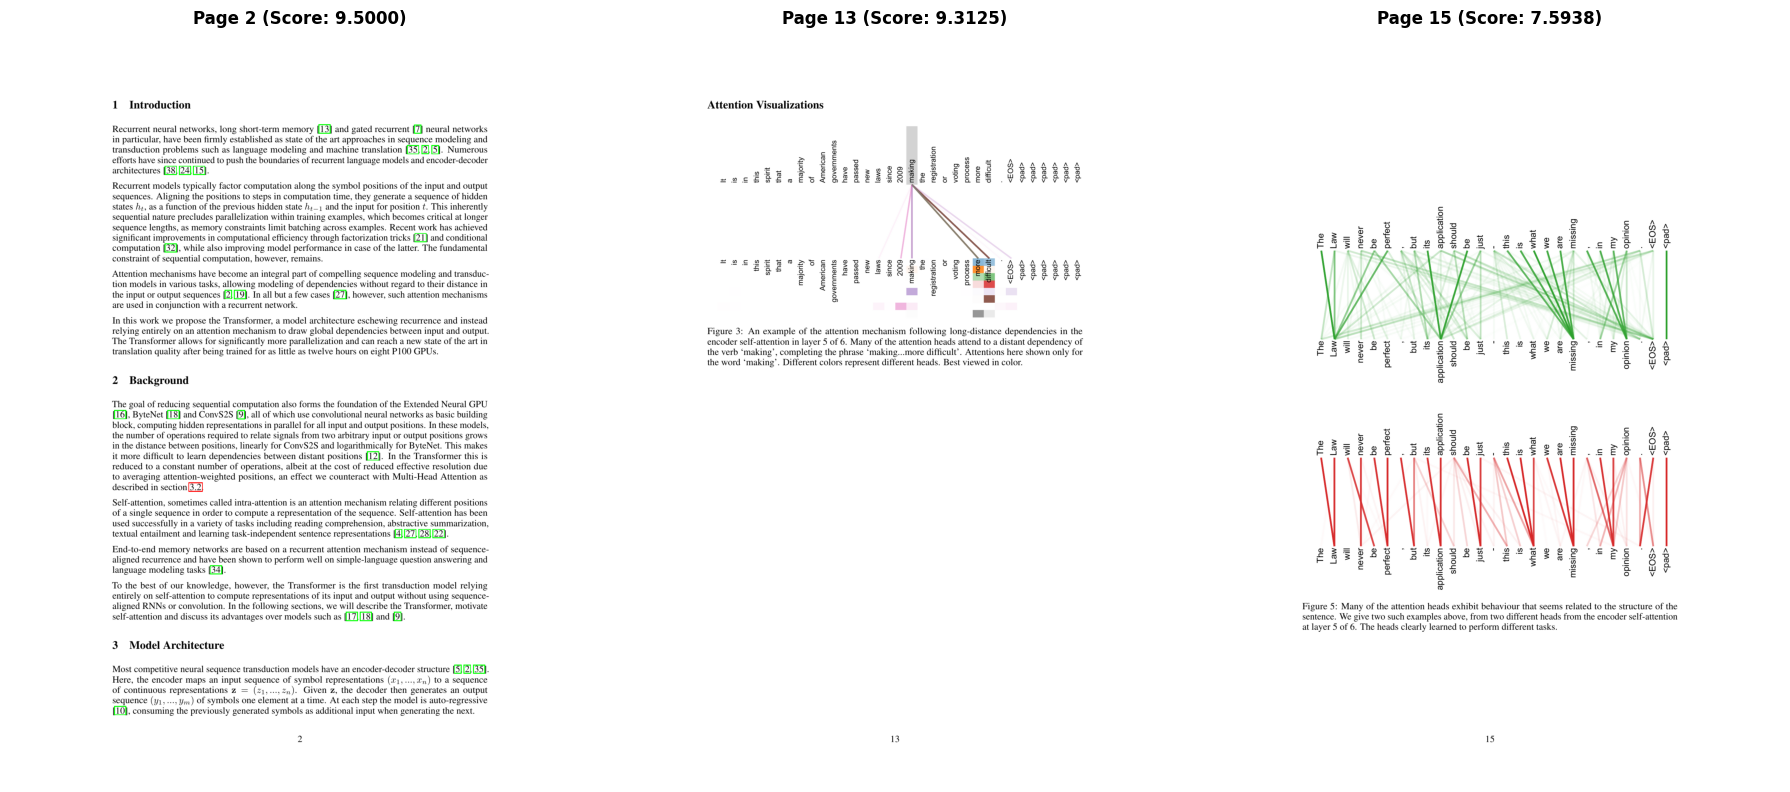

In [6]:
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

def display_search_results(results, max_display=3):
    """검색 결과 이미지 시각화"""
    num_results = min(len(results), max_display)

    if num_results == 0:
        print("검색 결과가 없습니다.")
        return

    fig, axes = plt.subplots(1, num_results, figsize=(6*num_results, 8))

    if num_results == 1:
        axes = [axes]

    for i, result in enumerate(results[:num_results]):
        ax = axes[i]

        if hasattr(result, 'base64') and result.base64:
            image_data = base64.b64decode(result.base64)
            image = Image.open(BytesIO(image_data))

            ax.imshow(image)
            ax.set_title(
                f"Page {result.page_num} (Score: {result.score:.4f})",
                fontsize=12,
                fontweight='bold'
            )
        else:
            ax.text(0.5, 0.5, "이미지 없음", ha='center', va='center')
            ax.set_title(f"Page {result.page_num}")

        ax.axis('off')

    plt.tight_layout()
    plt.show()


# 검색 결과 시각화
display_search_results(results, max_display=3)

### 2.5 다양한 쿼리 테스트


🔍 쿼리: transformer architecture encoder decoder
  [1] 페이지 3 | 점수: 12.6875
  [2] 페이지 5 | 점수: 11.1875


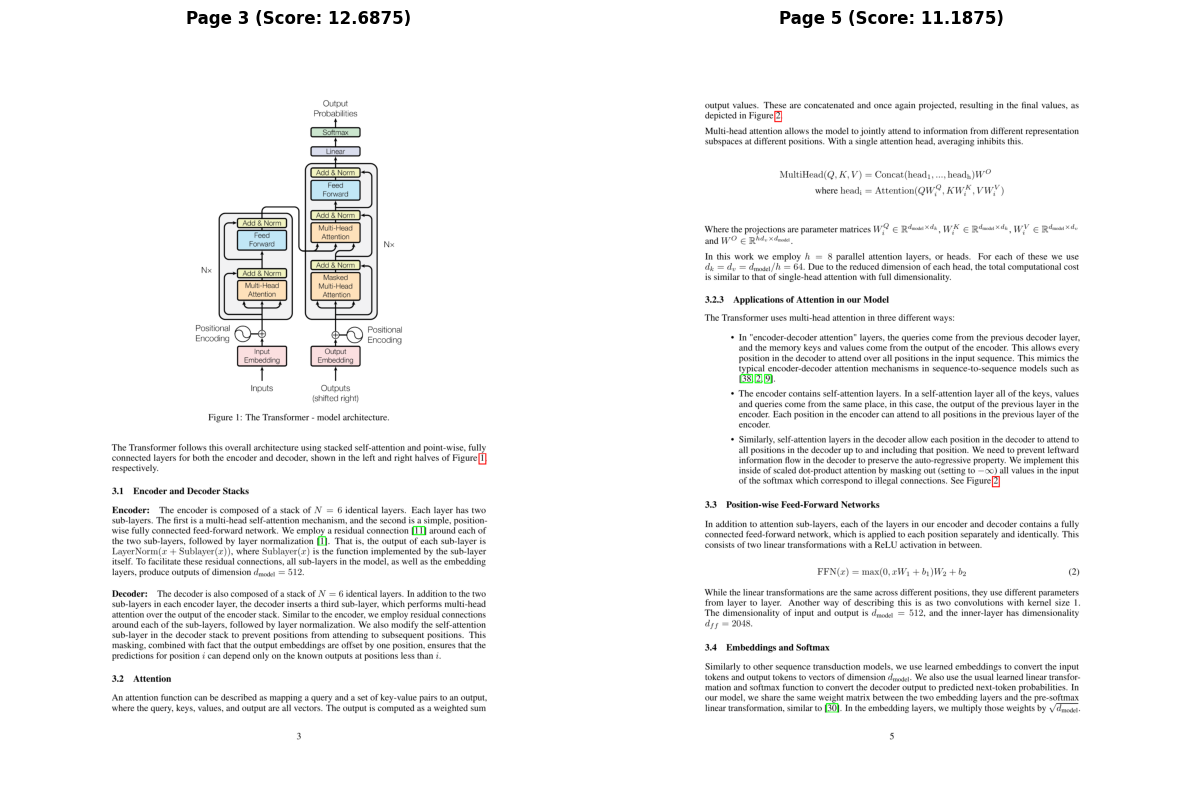


🔍 쿼리: multi-head attention
  [1] 페이지 5 | 점수: 11.1250
  [2] 페이지 4 | 점수: 10.5625


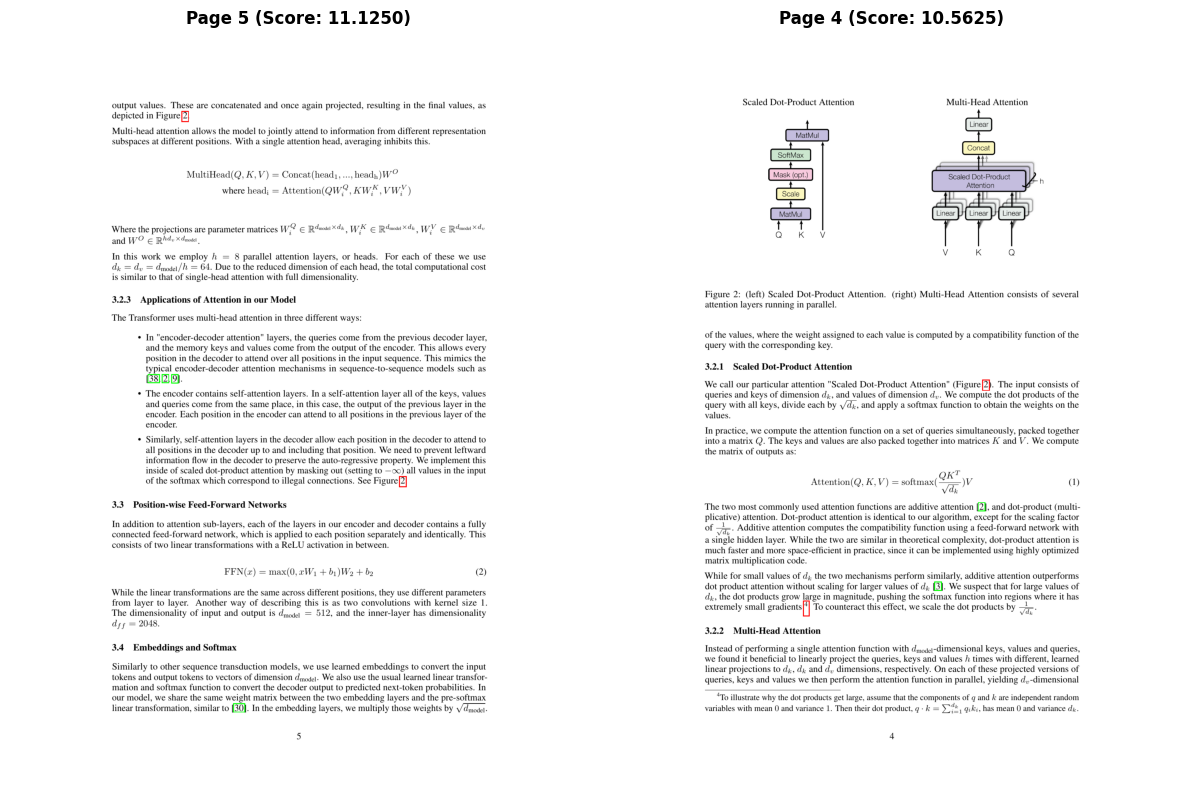


🔍 쿼리: positional encoding
  [1] 페이지 6 | 점수: 9.7500
  [2] 페이지 3 | 점수: 9.5000


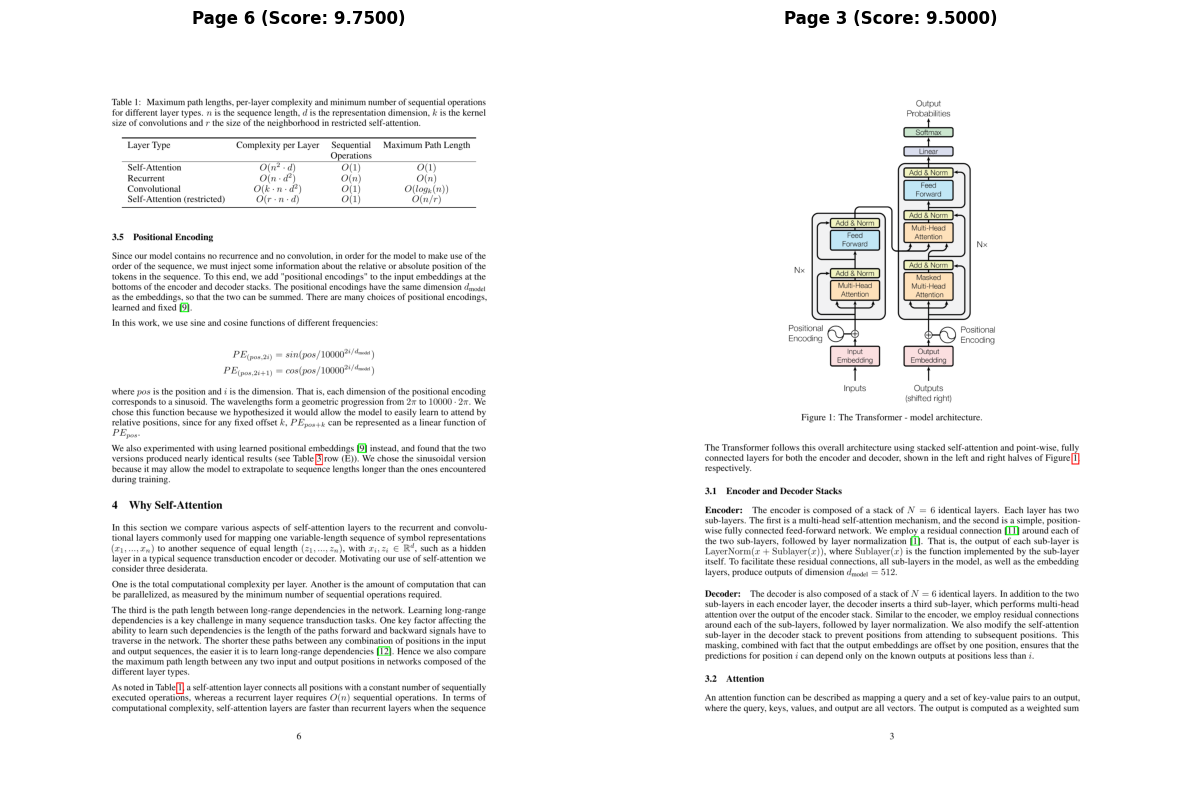


🔍 쿼리: BLEU score results
  [1] 페이지 8 | 점수: 9.8750
  [2] 페이지 1 | 점수: 8.1250


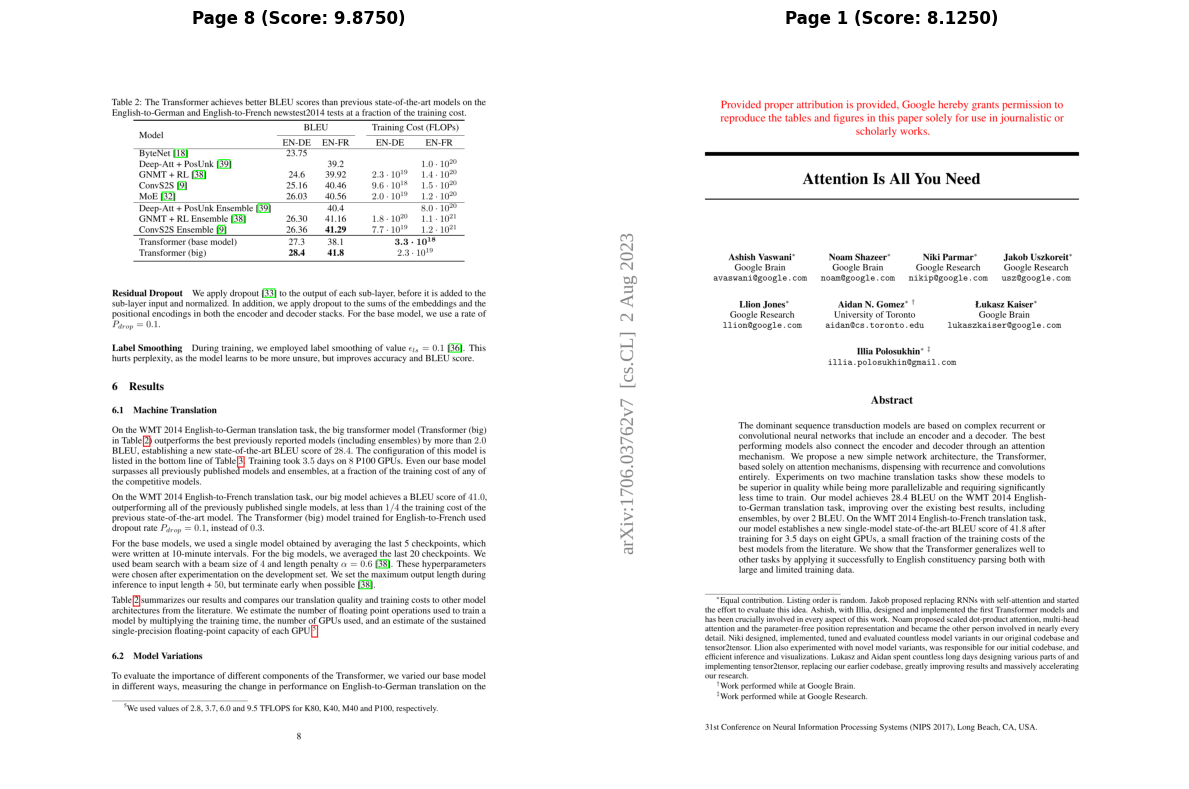

In [7]:
# 여러 쿼리로 검색 테스트
test_queries = [
    "transformer architecture encoder decoder",
    "multi-head attention",
    "positional encoding",
    "BLEU score results"
]

for query in test_queries:
    print(f"\n{'='*60}")
    print(f"🔍 쿼리: {query}")
    print(f"{'='*60}")

    results = RAG.search(query, k=2)

    for i, result in enumerate(results, 1):
        print(f"  [{i}] 페이지 {result.page_num} | 점수: {result.score:.4f}")

    # 검색 결과 시각화
    display_search_results(results, max_display=2)

---

## 3. VLM을 활용한 답변 생성

### 3.1 Retrieve-then-Generate 파이프라인

> 🔰 **쉽게**: ColQwen은 **검색만** 합니다. 답변은 못 해요. 그래서 VLM을 뒤에 붙여야 해요.

**파이프라인 구조**
```
[사용자 질문]
     ↓
📚 ColQwen (Retriever)    ← Top-k 페이지 선택 (MaxSim)
     ↓ (PIL 이미지들)
🤖 Qwen2-VL (Generator)   ← 이미지 보고 답변 생성
     ↓
[최종 답변]
```

> 💡 **비유**: 도서관의 **사서(검색)** vs **교수(답변)** 분업. 사서는 빠르게 책 찾고, 교수는 그 책만 보고 답하면 둘 다 잘합니다.

**왜 분리하나?**

| 이유 | 설명 |
|---|---|
| 🎯 **목적함수 차이** | Retriever=관련도, Generator=유창성·사실성 |
| ♻️ **인덱스 재사용** | 한번 인덱싱한 임베딩은 어떤 VLM과도 결합 가능 |
| 📏 **스케일 차이** | Retriever는 전체 DB, Generator는 Top-k만 |

**지연·비용 구조**

| 단계 | 빈도 | 모델 | 연산 |
|---|---|---|---|
| 인덱싱 | 문서 추가 시 1회 (**오프라인**) | ColQwen 2B | Vision forward |
| 검색 | 쿼리당 | ColQwen 2B (query만) | Text forward + MaxSim |
| 생성 | 쿼리당 | Qwen2-VL 2B (Top-k) | Autoregressive decode |

→ 서비스 지연 = **검색 + 생성** 합계

### 3.2 VLM 아키텍처 기본 구조

> 🔰 **쉽게**: VLM은 이미지와 텍스트를 **같은 언어 공간**으로 통역해서 LLM이 읽게 합니다.

**3단 구성**
```
[이미지]  →  👁 Vision Encoder   →  🔌 Projector  →  ┐
                                                       ├→ 🧠 LLM Decoder → 답변
[텍스트]  →  🔤 Tokenizer   ────────────────────────  ┘
```

| 구성 | 역할 |
|---|---|
| **Vision Encoder** | 이미지 → 패치 토큰 `(n_patches, d_vision)` |
| **Projector** | `d_vision` → `d_lm` 로 차원 맞춤 (2-layer MLP 또는 Q-Former) |
| **LLM Decoder** | 시각+언어 토큰을 하나의 시퀀스로 concat, `<image>` 자리에 패치 투입 |

**프롬프트 예시**
```python
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": pil_image_1},
        {"type": "image", "image": pil_image_2},
        {"type": "text",  "text": "이 두 페이지에서 Attention 구조를 설명해줘"},
    ],
}]
```

**내부 토큰 시퀀스**
```
<|im_start|>user
<|vision_start|> [img1 patches...] <|vision_end|>
<|vision_start|> [img2 patches...] <|vision_end|>
이 두 페이지에서 Attention 구조를 설명해줘
<|im_end|>
<|im_start|>assistant
```

**Qwen2-VL-2B-Instruct 스펙**
- Vision: Qwen-Vision (동적 해상도)
- LLM: Qwen2 1.5B decoder
- Context: 32k tokens
- 4-bit VRAM: ~3GB

### 3.3 Qwen3-VL로의 진화 (2026)

> 🔰 **쉽게**: 2026년 초 공개된 Qwen3-VL은 **긴 영상·작은 글자·수식**에서 크게 개선됐어요.

**라인업**

| 모델 | 아키 | 용도 |
|---|---|---|
| 2B Instruct | Dense | 엣지·Colab T4 |
| 4B Instruct | Dense | 일반 서버 |
| 8B/32B Instruct·Thinking | Dense | 고품질 |
| 30B-A3B | MoE (활성 3B) | 속도·품질 균형 |
| Embedding-2B | 임베딩 전용 | ※ Late Interaction 아님 |

**핵심 개선점 4가지**

| 기술 | 의미 |
|---|---|
| **Interleaved-MRoPE** | 시간축을 교차 배치 → 긴 영상 토큰 의존성 강화 |
| **DeepStack** | Vision 중간 레이어를 LLM에 다단 주입 → 작은 글자·수식 ↑ |
| **Text-Timestamp Alignment** | 영상 토큰-시간 명시 정렬 → "몇 분 장면?" 가능 |
| **Thinking 에디션** | CoT 추론 내장 (o1/Gemini-Thinking과 유사) |

**요구사항**
- `transformers >= 4.57.1` (4.57.0은 yanked)
- 2B Instruct는 T4 + 4-bit 로 실행 가능
- 8B 이상은 A100/H100 권장

**왜 본 노트북은 Qwen2-VL 고정?**
- Colab T4 검증 안정성, transformers 호환성 리스크 최소화
- 개념 학습 단계에선 모델 교체는 부차적 → **섹션 5**에서 Qwen3-VL 교체 실험 제공

### 3.4 Qwen2-VL 모델 로드

In [8]:
import torch
import gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

vlm_model_name = "Qwen/Qwen2-VL-2B-Instruct"

# Colab(T4 16GB)에서는 4-bit 양자화로 VLM 을 압축해 ColQwen2 와 동시 상주시킨다.
# 로컬에 여유 VRAM 이 있으면 양자화 없이 fp16/bf16 으로 올리는 편이 품질에 유리.
use_quantization = IN_COLAB

if use_quantization:
    from transformers import BitsAndBytesConfig

    print("📦 4-bit 양자화 활성화 (Colab 환경)")
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,  # T4는 bfloat16 지원 제한적
        bnb_4bit_quant_type="nf4",          # 정규분포 quantile 기반 4bit (§3.5)
        bnb_4bit_use_double_quant=True,     # 스케일 상수까지 8bit 로 재양자화 → 추가 ~0.4bit/param 절약
    )

    vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
        vlm_model_name,
        quantization_config=quantization_config,
        device_map="auto",
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )
else:
    vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
        vlm_model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None
    )

    if device == "mps":
        vlm_model = vlm_model.to(device)

vlm_processor = AutoProcessor.from_pretrained(vlm_model_name)

print(f"✅ Qwen2-VL 모델 로드 완료: {vlm_model_name}")
if torch.cuda.is_available():
    print(f"   현재 GPU 메모리: {torch.cuda.memory_allocated()/1024**3:.2f}GB 사용 중")

📦 4-bit 양자화 활성화 (Colab 환경)


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Qwen2-VL 모델 로드 완료: Qwen/Qwen2-VL-2B-Instruct
   현재 GPU 메모리: 5.61GB 사용 중


### 3.5 NF4와 Double Quantization

> 🔰 **쉽게**: 4-bit로 압축하면 모델이 1/3로 작아져요. 비결은 **가중치 분포에 맞는 양자화**(NF4) + **스케일 상수도 압축**(Double Quant).

**참고**: QLoRA 논문 (Dettmers et al., **NeurIPS 2023**)

---

**① NF4 (NormalFloat 4-bit)**

- 일반 Int4: `[-8, -7, ..., 7]` **균등** 16단계
- **NF4**: 가중치가 **정규분포 N(0,σ²)** 를 따른다는 관찰 → 16단계를 **정규분포 quantile**로 배치
- 결과: Int4 대비 정확도 손실 **절반**

> 💡 **비유**: 옷 사이즈를 1~16 균등(S/M/L만 16칸)으로 자르면 어색. **실제 키 분포**에 맞춰 16단계 정하면 훨씬 잘 맞아요. NF4가 후자.

---

**② Double Quantization**

- 4-bit 저장 시 블록(64~256개)마다 **스케일 상수** (fp16/32) 필요 → 이 상수 자체를 또 8-bit로 양자화
- 추가 절약: **~0.4 bits/param** (Qwen2-VL-2B 기준 ~100MB)

---

**③ compute_dtype 선택**
```python
bnb_4bit_compute_dtype=torch.float16,   # T4 환경
```

| GPU | 권장 dtype |
|---|---|
| Turing (T4) | `float16` |
| Ampere+ (A100, H100) | `bfloat16` (수치 안정성 ↑) |

---

**VRAM 절약 효과 (Qwen2-VL-2B)**

| 설정 | VRAM |
|---|---|
| FP16 | ~4.5 GB |
| 4-bit (NF4만) | ~1.8 GB |
| **4-bit + Double Quant** | **~1.5 GB** |

→ T4(16GB)에 ColQwen + Qwen2-VL **동시 로드** 가능 (~7GB 사용, 여유 충분)

**실무 팁**
- Qwen-VL 계열은 4-bit에서도 성능 저하 미미 → 4-bit가 표준
- QLoRA 파인튜닝 기본 조합: `nf4 + double_quant`

### 3.6 RAG 파이프라인 구현

In [9]:
import io
import base64
import gc
from PIL import Image
from qwen_vl_utils import process_vision_info

def multimodal_rag_pipeline(query: str, top_k: int = 2, max_new_tokens: int = 256):
    """
    멀티모달 RAG 파이프라인: ColQwen 검색 + Qwen2-VL 생성

    Args:
        query: 검색 쿼리
        top_k: 검색할 상위 문서 수 (Colab에서는 1-2 권장)
        max_new_tokens: 생성할 최대 토큰 수 (메모리 절약을 위해 256 권장)

    Returns:
        생성된 답변 문자열
    """
    try:
        # 1. ColQwen 검색
        print(f"🔍 검색 중: {query}")
        search_results = RAG.search(query, k=top_k)

        if not search_results:
            return "❌ 검색 결과가 없습니다. 다른 키워드로 시도해보세요."

        print(f"✅ {len(search_results)}개 페이지 검색 완료")
        for i, result in enumerate(search_results):
            print(f"   [{i+1}] 페이지 {result.page_num}, 점수: {result.score:.4f}")

        # 2. 검색된 이미지 준비
        #    ⚠️ 여기서 줄인 해상도가 곧 VLM 이 읽을 수 있는 글자 크기의 상한이 된다.
        #       작은 수식·각주를 놓친다면 이 값을 (1024, 1024) 로 올려 볼 것.
        images = []
        max_size = (640, 640) if IN_COLAB else (1024, 1024)  # Colab에서 해상도 더 제한

        for result in search_results:
            if hasattr(result, 'base64') and result.base64:
                image_data = base64.b64decode(result.base64)
                image = Image.open(io.BytesIO(image_data)).convert("RGB")

                # 이미지 리사이즈 (메모리 절약)
                image.thumbnail(max_size, Image.Resampling.LANCZOS)
                images.append(image)

        if not images:
            return "❌ 검색 결과에 이미지가 없습니다. store_collection_with_index=True로 인덱싱하세요."

        # 3. VLM 입력 구성
        messages = [
            {
                "role": "user",
                "content": [
                    *[{"type": "image", "image": img} for img in images],
                    {"type": "text", "text": f"Based on the document images, answer the question.\n\nQuestion: {query}\n\nAnswer:"}
                ]
            }
        ]

        # 4. 답변 생성
        print("🤖 답변 생성 중...")

        # 메모리 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # 대화 템플릿 적용: <|vision_start|> ... <|vision_end|> 자리표시자가 삽입된 문자열이 나온다
        text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        # process_vision_info: Qwen2-VL 전용 유틸 (messages 에서 이미지/비디오를 꺼내 규격화)
        #   ※ Qwen3-VL 에서는 불필요 — PIL 이미지를 processor 에 직접 전달한다 (§5)

        image_inputs, video_inputs = process_vision_info(messages)
        inputs = vlm_processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to(vlm_model.device)

        # 중간 변수 정리
        del image_inputs, video_inputs, images, messages
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        with torch.no_grad():
            generated_ids = vlm_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # greedy: 재현 가능한 결정론적 출력 (교육용으로 중요)
                pad_token_id=vlm_processor.tokenizer.pad_token_id,
            )

        # 입력 프롬프트 부분을 잘라내야 답변만 남는다.
        # generate() 는 [프롬프트 토큰 + 생성 토큰] 전체를 반환하기 때문.
        generated_ids_trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        response = vlm_processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        # GPU 메모리 정리
        del inputs, generated_ids, generated_ids_trimmed
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("✅ 답변 생성 완료")
        return response

    except torch.cuda.OutOfMemoryError:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return "❌ GPU 메모리 부족. top_k=1로 줄이거나 런타임을 재시작하세요."
    except Exception as e:
        import traceback
        traceback.print_exc()
        return f"❌ 오류 발생: {type(e).__name__}: {str(e)}"

### 3.7 RAG 파이프라인 실행

In [10]:
# 질문 예시 (Colab에서는 top_k=1로 메모리 절약)
query = "What is the attention mechanism in transformers?"

# Colab에서는 이미지 1개만 사용하여 메모리 절약
top_k_value = 1 if IN_COLAB else 3
answer = multimodal_rag_pipeline(query, top_k=top_k_value, max_new_tokens=200)

print("\n" + "="*60)
print(f"❓ 질문: {query}")
print("="*60)
print(f"\n💡 답변:\n{answer}")

🔍 검색 중: What is the attention mechanism in transformers?
✅ 1개 페이지 검색 완료
   [1] 페이지 2, 점수: 13.8125
🤖 답변 생성 중...


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ 답변 생성 완료

❓ 질문: What is the attention mechanism in transformers?

💡 답변:
Attention mechanisms have become an integral part of compelling sequence modeling and transcucion models in various tasks, allowing modeling of dependencies without regard to their distance in the input or output sequences.


In [11]:
# 여러 질문 테스트 (Colab에서는 top_k=1로 더 줄임)
test_questions = [
    "How does multi-head attention work?",
    "What is positional encoding?",
]

top_k_value = 1 if IN_COLAB else 2

for question in test_questions:
    print("\n" + "="*80)
    print(f"❓ 질문: {question}")
    print("="*80)

    answer = multimodal_rag_pipeline(question, top_k=top_k_value)
    print(f"\n💡 답변:\n{answer}")


❓ 질문: How does multi-head attention work?
🔍 검색 중: How does multi-head attention work?
✅ 1개 페이지 검색 완료
   [1] 페이지 4, 점수: 15.1250
🤖 답변 생성 중...
✅ 답변 생성 완료

💡 답변:
Multi-head attention consists of several attention layers running in parallel. The input consists of queries and keys of dimension d_k and values of dimension d_v. We compute the dot products of the query with all keys, divide each by √d_k, and apply a softmax function to obtain the weights on the values. In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix Q. The keys and values are also packed together into matrices K and V. We compute the matrix of outputs as: Attention(Q, K, V) = softmax(√d_k)QKVT (1) The two most commonly used attention functions are additive attention [3], and dot-product (multi- plicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor of 1/√d_k. Additive attention computes the compatibility function 

---

## 4. colpali-engine으로 ColQwen2.5 전환

**colpali-engine**은 최신 ColQwen2.5 모델을 지원합니다.

In [12]:
import torch
import gc
from PIL import Image
from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

# Colab에서는 이전 모델 정리 필요
if IN_COLAB:
    print("🧹 이전 모델 메모리 정리 중...")

    # VLM 모델 정리
    if 'vlm_model' in dir():
        del vlm_model
        print("   - Qwen2-VL 모델 삭제")

    if 'vlm_processor' in dir():
        del vlm_processor

    # byaldi RAG 모델 정리
    if 'RAG' in dir():
        del RAG
        print("   - ColQwen2 (byaldi) 모델 삭제")

    # 메모리 해제 3종 세트 — 셋 다 필요하다:
    #   del            : 파이썬 참조를 끊는다 (이것만으로는 GPU 메모리가 안 빠진다)
    #   gc.collect()   : 순환 참조까지 수거해 텐서 소멸자를 실제로 호출
    #   empty_cache()  : PyTorch 캐싱 할당자가 쥔 블록을 드라이버에 반환
    gc.collect()
    torch.cuda.empty_cache()
    print(f"   GPU 메모리 정리 완료: {torch.cuda.memory_allocated()/1024**3:.2f}GB 사용 중")

# ColQwen2.5 모델 로드
colqwen25_device = device
print(f"\n🔧 ColQwen2.5 디바이스: {colqwen25_device}")

# T4(Turing, SM7.5)에는 bfloat16 텐서코어가 없다 → float16 사용.
# Ampere(A100) 이상에서는 수치 안정성이 좋은 bfloat16 이 권장값이다.
# 참고: 최신 transformers 는 torch_dtype 대신 dtype 인자를 표준으로 삼는다(별칭 유지).
if IN_COLAB:
    model_colqwen25 = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.float16,
        device_map="auto",
        low_cpu_mem_usage=True,
    ).eval()
else:
    model_colqwen25 = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.bfloat16 if colqwen25_device != "cpu" else torch.float32,
        device_map=colqwen25_device if colqwen25_device == "cuda" else None,
    ).eval()

    if colqwen25_device != "cuda":
        model_colqwen25 = model_colqwen25.to(colqwen25_device)

processor_colqwen25 = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")

print("✅ ColQwen2.5 모델 로드 완료")
if torch.cuda.is_available():
    print(f"   현재 GPU 메모리: {torch.cuda.memory_allocated()/1024**3:.2f}GB 사용 중")

🧹 이전 모델 메모리 정리 중...
   - Qwen2-VL 모델 삭제
   - ColQwen2 (byaldi) 모델 삭제
   GPU 메모리 정리 완료: 0.01GB 사용 중

🔧 ColQwen2.5 디바이스: cuda


adapter_config.json:   0%|          | 0.00/813 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

✅ ColQwen2.5 모델 로드 완료
   현재 GPU 메모리: 7.11GB 사용 중


In [13]:
from pdf2image import convert_from_path

# PDF → PIL 이미지 (poppler 필요)
# DPI 를 올려도 프로세서의 max_pixels(=602112, 768토큰) 상한에 걸려 토큰 수는 그대로다.
# 세부 인식을 더 높이려면 DPI 가 아니라 max_num_visual_tokens 상한을 올려야 한다.
dpi_value = 100 if IN_COLAB else 150
pdf_images = convert_from_path(str(pdf_path), dpi=dpi_value)
print(f"✅ {len(pdf_images)}개 페이지 변환 완료 (DPI: {dpi_value})")

# 문서 임베딩 생성
print("📄 문서 임베딩 생성 중...")
doc_embeddings = []

with torch.no_grad():
    for i, img in enumerate(pdf_images):
        # [전처리] smart_resize → 14px 패치 → 2×2 병합 → 프롬프트 결합 (§1.5 ①~④)
        #   반환: pixel_values, image_grid_thw, input_ids, attention_mask
        batch_images = processor_colqwen25.process_images([img]).to(model_colqwen25.device)

        # [인코딩] LLM last_hidden_state → Linear(2048→128) → L2 정규화 (§1.5 ⑤~⑥)
        #   생성(generate)이 아니라 인코딩만 수행한다. shape ≈ (1, 783, 128)
        embedding = model_colqwen25(**batch_images)

        # ⭐ 핵심 최적화: 임베딩을 CPU 로 옮겨 GPU 에 쌓이지 않게 한다.
        #    이 한 줄이 없으면 페이지 수에 비례해 VRAM 이 늘어 수백 페이지에서 반드시 OOM.
        #    검색 시점에만 다시 GPU 로 올리면 되므로 비용은 거의 없다.
        doc_embeddings.append(embedding.cpu())

        # 중간 변수 정리
        del batch_images, embedding

        # 페이지마다 시각 토큰 수가 달라 할당 블록 크기가 제각각 → 단편화가 쌓인다.
        # 주기적으로 캐시를 반환해 T4 에서의 OOM 을 예방.
        if (i + 1) % 5 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            print(f"   {i + 1}/{len(pdf_images)} 페이지 완료")

print(f"✅ 총 {len(doc_embeddings)}개 페이지 임베딩 완료")
if torch.cuda.is_available():
    print(f"   현재 GPU 메모리: {torch.cuda.memory_allocated()/1024**3:.2f}GB 사용 중")

✅ 15개 페이지 변환 완료 (DPI: 100)
📄 문서 임베딩 생성 중...
   5/15 페이지 완료
   10/15 페이지 완료
   15/15 페이지 완료
✅ 총 15개 페이지 임베딩 완료
   현재 GPU 메모리: 7.11GB 사용 중


In [14]:
def search_colqwen25(query: str, top_k: int = 3):
    """
    ColQwen2.5를 사용한 시각적 검색

    Args:
        query: 검색 쿼리
        top_k: 반환할 상위 결과 수

    Returns:
        검색 결과 리스트 [{"page": int, "score": float, "image": PIL.Image}, ...]
    """
    with torch.no_grad():
        # 쿼리도 '같은 모델'을 통과한다 (이미지 없이 텍스트만). shape ≈ (1, 25, 128)
        #   내부에서 query + '<|endoftext|>'×10 (query augmentation) 이 붙는다 — §1.5 ③-③
        batch_queries = processor_colqwen25.process_queries([query]).to(model_colqwen25.device)
        query_embedding = model_colqwen25(**batch_queries)

    # MaxSim 점수 계산
    # ⚠️ 페이지마다 순차 호출하는 O(N) 루프다. 15페이지라 문제없지만
    #    수천 페이지부터는 임베딩을 패딩해 배치 행렬곱으로 한 번에 계산하거나
    #    Vespa/Qdrant 의 multi-vector 인덱스를 써야 한다.
    scores = []
    for doc_emb in doc_embeddings:
        # doc_emb가 CPU에 있으면 GPU로 이동
        doc_emb_device = doc_emb.to(model_colqwen25.device)
        # MaxSim: einsum("bnd,csd->bcns").amax(3).sum(2)  → (1, 1) 행렬에서 스칼라 추출
        # ⚠️ 정규화되지 않은 '합'이라 쿼리 길이에 비례한다 → 전역 임계값 사용 금지 (§1.3)
        score = processor_colqwen25.score_multi_vector(query_embedding, doc_emb_device)[0].item()
        scores.append(score)
        del doc_emb_device  # 메모리 정리

    # 상위 k개 결과
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]

    # 메모리 정리
    del batch_queries, query_embedding
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # idx 는 0-index 배열 위치 → 사람이 읽는 페이지 번호로 바꾸려면 +1
    return [
        {"page": idx + 1, "score": scores[idx], "image": pdf_images[idx]}
        for idx in top_indices
    ]


# 검색 테스트
query = "attention mechanism"
results = search_colqwen25(query, top_k=3)

print(f"🔍 쿼리: {query}")
print("=" * 60)
for r in results:
    print(f"   페이지 {r['page']}: {r['score']:.4f}")

🔍 쿼리: attention mechanism
   페이지 13: 9.4375
   페이지 2: 9.0703
   페이지 4: 8.8125


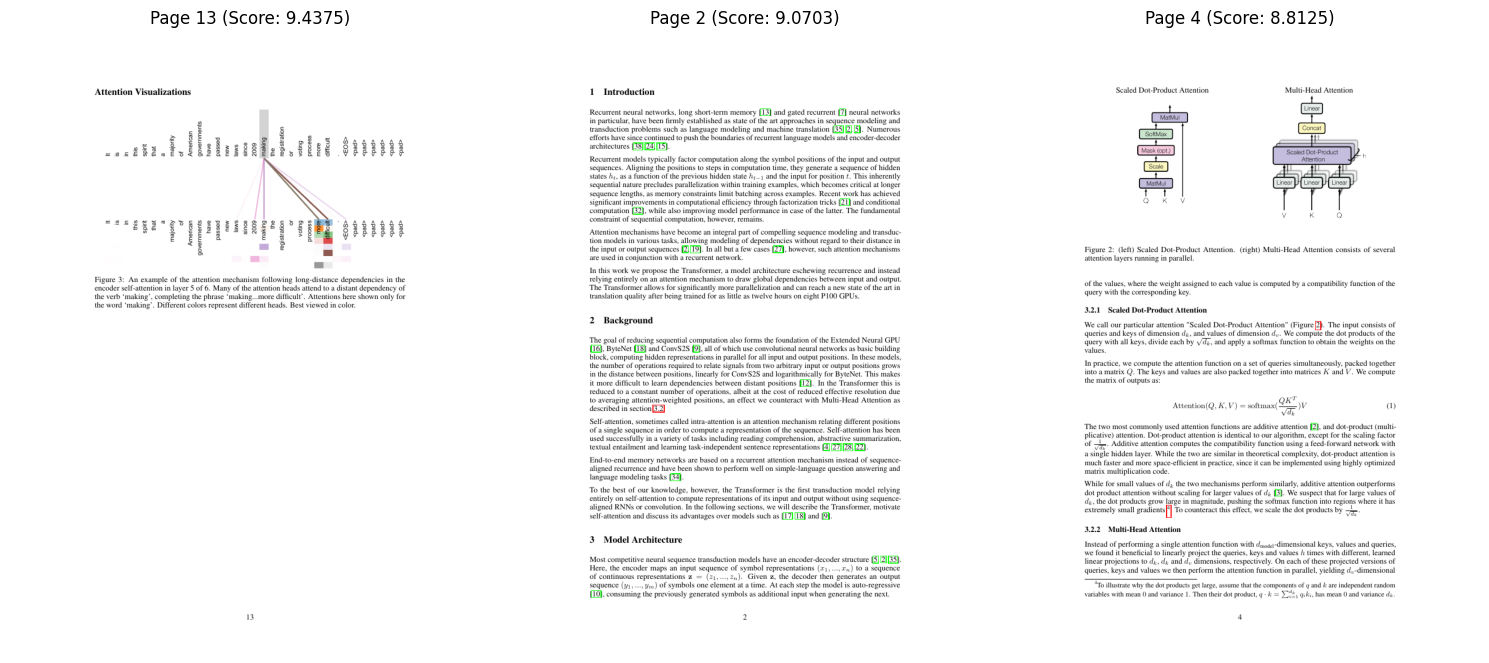

35

In [15]:
# 검색 결과 시각화
import matplotlib.pyplot as plt

num_results = min(len(results), 3)  # 최대 3개만 표시
fig, axes = plt.subplots(1, num_results, figsize=(5*num_results, 7))

if num_results == 1:
    axes = [axes]

for i, r in enumerate(results[:num_results]):
    axes[i].imshow(r['image'])
    axes[i].set_title(f"Page {r['page']} (Score: {r['score']:.4f})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 메모리 정리
plt.close(fig)
gc.collect()

## 5. (선택) Qwen3-VL-2B-Instruct 교체 실험

위 섹션에서 구축한 ColQwen2.5 검색 인덱스(`doc_embeddings`, `pdf_images`)는 그대로 두고
**답변 생성용 VLM만 Qwen3-VL-2B-Instruct로 교체**해봅니다.
Retrieve-then-Generate 구조에서는 **Generator만 갈아 끼우면 되고, 인덱스를 다시 만들 필요가 없다**는 점이 핵심입니다

In [16]:
# [선택] Qwen3-VL-2B-Instruct로 교체 실험
# 주의: transformers >= 4.57.1 필요 (⚠️ 4.57.0 은 PyPI 에서 yanked 되었으므로 그 버전을 고정하지 말 것)
# !pip install -q -U "transformers>=4.57.1"

import torch, gc
from transformers import AutoProcessor
try:
    from transformers import Qwen3VLForConditionalGeneration  # transformers >= 4.57.1
except ImportError:
    print("❌ transformers>=4.57.0 필요. 위 주석의 pip 명령을 활성화하세요.")
    raise

# 이전 모델 메모리 정리
# ⚠️ 여기서 검색기(model_colqwen25)까지 지운다는 점에 주의!
#    T4 여유 확보가 목적이며, 다음 셀 앞부분에서 4-bit 로 재로드한다.
for name in ["vlm_model", "vlm_processor", "model_colqwen25"]:
    if name in dir():
        exec(f"del {name}")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

qwen3_model_name = "Qwen/Qwen3-VL-2B-Instruct"

# 4-bit 양자화 (T4 기준)
from transformers import BitsAndBytesConfig
qconfig = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

qwen3_model = Qwen3VLForConditionalGeneration.from_pretrained(
    qwen3_model_name,
    quantization_config=qconfig,
    device_map="auto",
)
qwen3_processor = AutoProcessor.from_pretrained(qwen3_model_name)
print(f"✅ {qwen3_model_name} 로드 완료")

# Qwen2-VL 과의 차이는 3가지뿐:
#   1) 클래스명: Qwen3VLForConditionalGeneration
#   2) process_vision_info 불필요 → PIL 이미지를 processor 에 직접 전달
#   3) generate() 전에 inputs.pop("token_type_ids", None) 필수 (공식 예제 라인)
# 실제 사용은 다음 셀 참고.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✅ Qwen/Qwen3-VL-2B-Instruct 로드 완료


In [21]:
# Qwen3-VL 답변 생성 파이프라인
# 전제: 섹션 4 에서 search_colqwen25 / pdf_images / doc_embeddings 준비됨
#       직전 셀에서 qwen3_model / qwen3_processor 로드됨
# 인덱스(doc_embeddings)는 그대로 재사용한다 = Retrieve-then-Generate 의 이점(§3.1)

from PIL import Image

# ── ColQwen2.5 재로드 가드 ─────────────────────────────────────────────
# ColQwen2.5 를 4-bit 로 재로드 (Qwen3-VL 과 공존)
import gc, torch
if 'model_colqwen25' in dir():
    del model_colqwen25
gc.collect(); torch.cuda.empty_cache()

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor
from transformers import BitsAndBytesConfig

qconfig_colqwen = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model_colqwen25 = ColQwen2_5.from_pretrained(
    "vidore/colqwen2.5-v0.2",
    quantization_config=qconfig_colqwen,
    torch_dtype=torch.float16,   # ← 핵심: Qwen3-VL 과 compute dtype 을 맞춘다.
                                 #    불일치 시 'expected scalar type Half but found Float' 발생
    device_map="auto",
    low_cpu_mem_usage=True,
).eval()
processor_colqwen25 = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")
print(f"✅ 재로드 완료 — GPU: {torch.cuda.memory_allocated()/1024**3:.2f}GB")


def multimodal_rag_pipeline_qwen3(query: str, top_k: int = 1, max_new_tokens: int = 256):
    """ColQwen2.5 검색 + Qwen3-VL-2B-Instruct 답변 생성."""

    # 1) 시각적 검색 (ColQwen2.5)
    print(f"🔍 검색 중: {query}")
    results = search_colqwen25(query, top_k=top_k)
    print(f"✅ {len(results)}개 페이지 검색 완료")
    for r in results:
        print(f"   페이지 {r['page']}: {r['score']:.4f}")

    # 2) 이미지 준비 (T4 메모리 보호 위해 다운스케일)
    max_size = (640, 640) if IN_COLAB else (1024, 1024)
    images = []
    for r in results:
        img = r["image"].convert("RGB").copy()
        img.thumbnail(max_size, Image.Resampling.LANCZOS)
        images.append(img)

    # 3) Qwen3-VL 메시지 구성 (Qwen2-VL 과 포맷 동일)
    messages = [
        {
            "role": "user",
            "content": [
                *[{"type": "image", "image": img} for img in images],
                {
                    "type": "text",
                    "text": (
                        "Based on the document images, answer the question.\n\n"
                        f"Question: {query}\n\nAnswer:"
                    ),
                },
            ],
        }
    ]

    # 4) 입력 텐서 생성 — Qwen3-VL 은 process_vision_info 불필요 (PIL 직접 전달)
    text = qwen3_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qwen3_processor(
        text=[text],
        images=images,
        padding=True,
        return_tensors="pt",
    ).to(qwen3_model.device)

    # ⚠️ Qwen3-VL 필수 fix: processor 가 반환한 token_type_ids 는 generate() 에서 오류 유발
    inputs.pop("token_type_ids", None)

    # 5) 생성 (greedy, 메모리 절약)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    with torch.no_grad():
        generated_ids = qwen3_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=qwen3_processor.tokenizer.pad_token_id,
        )

    # 6) 입력 프롬프트 부분 제거 후 디코드
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    response = qwen3_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    # 메모리 정리
    del inputs, generated_ids, generated_ids_trimmed
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return response


# === 실행 예시 ===
top_k_value = 1 if IN_COLAB else 2
query = "What is the attention mechanism in transformers?"
answer = multimodal_rag_pipeline_qwen3(
    query, top_k=top_k_value, max_new_tokens=200
)

print("\n" + "=" * 60)
print(f"❓ 질문: {query}")
print("=" * 60)
print(f"\n💡 답변:\n{answer}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/826 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/506 [00:00<?, ?it/s]

✅ 재로드 완료 — GPU: 3.84GB
🔍 검색 중: What is the attention mechanism in transformers?
✅ 1개 페이지 검색 완료
   페이지 3: 13.9375

❓ 질문: What is the attention mechanism in transformers?

💡 답변:
Based on the provided document, the attention mechanism in Transformers is described as a multi-head self-attention mechanism. The text states that the first layer uses a multi-head self-attention mechanism, and the second layer uses a residual connection. The attention mechanism is also described as a self-attention mechanism, where the attention score is computed as a weighted sum of the query, keys, and values.


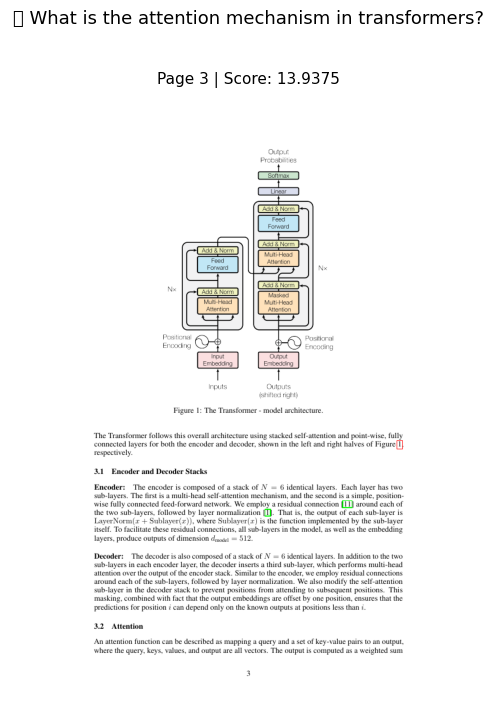

🔍 검색 중: What is the attention mechanism in transformers?
✅ 1개 페이지 검색 완료
   페이지 3: 13.9375

❓ What is the attention mechanism in transformers?

💡 답변:
Based on the provided document, the attention mechanism in Transformers is described as a multi-head self-attention mechanism. The text states that the first layer uses a multi-head self-attention mechanism, and the second layer uses a residual connection. The attention mechanism is also described as a self-attention mechanism, where the attention score is computed as a weighted sum of the query, keys, and values.


In [22]:
# 검색 결과 시각화 + Qwen3-VL 답변 생성 (래퍼)
import matplotlib.pyplot as plt


def rag_pipeline_qwen3_with_display(
    query: str,
    top_k: int = 1,
    max_new_tokens: int = 256,
    show_images: bool = True,
):
    """검색된 페이지 이미지를 표시한 뒤 Qwen3-VL 로 답변 생성."""

    # 1) 검색 결과 시각화
    if show_images:
        results = search_colqwen25(query, top_k=top_k)
        fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 7))
        if len(results) == 1:
            axes = [axes]
        for ax, r in zip(axes, results):
            ax.imshow(r["image"])
            ax.set_title(f"Page {r['page']} | Score: {r['score']:.4f}", fontsize=11)
            ax.axis("off")
        plt.suptitle(f"🔍 {query}", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

    # 2) 답변 생성 (기존 함수 재사용)
    answer = multimodal_rag_pipeline_qwen3(
        query, top_k=top_k, max_new_tokens=max_new_tokens
    )

    print("\n" + "=" * 60)
    print(f"❓ {query}")
    print("=" * 60)
    print(f"\n💡 답변:\n{answer}")
    return answer


# === 사용 예시 ===
_ = rag_pipeline_qwen3_with_display(
    "What is the attention mechanism in transformers?",
    top_k=1 if IN_COLAB else 2,
    max_new_tokens=200,
)